# Código atualizado


In [7]:
# ============================================
# 0) Imports
# ============================================
import warnings

import numpy as np
import pandas as pd
import numpy as np

# from dataclasses import dataclass
# from typing import Callable, List, Tuple, Dict, Any, Optional
# from datetime import datetime

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_validate
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
# from sklearn.metrics import (
#     accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score,
#     confusion_matrix, classification_report
# )

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
# from itertools import combinations
# from sklearn.preprocessing import PolynomialFeatures

import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


In [8]:
# ============================================
# 1) Carregar datasets
# ============================================
DATASET_TSALLIS = 'dataset_tsallis.csv'

df = pd.read_csv(DATASET_TSALLIS)

print("Shape: ", df.shape)
df.head()

Shape:  (81, 20)


,mfcc13_std,mfcc11_std,mfcc2_mean,shimmer_local,dmfcc6_std,dmfcc13_std,mfcc10_std,mfcc3_std,mfcc1_std,dmfcc3_mean,dmfcc13_mean,mfcc9_std,dmfcc10_std,mfcc1_mean,dmfcc7_std,spec_centroid_mean_hz,status,subject_id,tsallis_sq_amp,tsallis_sq_f0
0,1.194686,1.515766,143.437123,0.037484,0.287354,0.192115,2.477908,3.687953,3.331886,0.002169,-0.003259,1.627204,0.267359,-179.871006,0.315555,991.875771,0,064F,2.175084,0.471591
1,2.868343,2.478887,143.418929,0.097744,0.712286,0.392799,2.723828,8.561224,15.433386,0.067474,-0.007446,4.002862,0.431814,-200.541864,0.560031,824.346187,0,114S,2.150822,0.619451
2,2.088645,2.389130,141.246091,0.042938,0.391642,0.362853,3.198170,7.696958,7.138433,0.026451,-0.017632,4.187925,0.411820,-187.033630,0.451121,787.583484,0,121A,2.141979,0.000000
3,1.638525,2.120236,149.622240,0.052954,0.360981,0.222997,1.971154,4.814988,7.193395,0.001478,-0.001005,2.780914,0.287592,-175.580985,0.289940,864.637521,0,123G,2.144335,0.000000
4,2.948474,2.715525,130.595382,0.069098,0.600053,0.492086,2.714210,6.895219,11.341805,0.068457,0.013233,3.253537,0.514678,-200.951770,0.409324,1088.249820,0,195B,2.157088,0.285120


In [9]:
# ============================================
# 42) Preparar X, y e grupos
# Removemos metadados e o target das features
# ============================================

cols_to_drop = ["status", "subject_id"]
feature_cols = [c for c in df.columns if c not in cols_to_drop]

X = df[feature_cols]
y = df["status"].astype(int)
groups = df["subject_id"]

print("Colunas a serem descartadas:", cols_to_drop)
print("Colunas de features:", feature_cols)
print(len(feature_cols), "features selecionadas.")
print("\nBalanceamento:")
print(pd.Series(y).value_counts().rename(index={0: "Controle(0)", 1: "Parkinson(1)"}))

Colunas a serem descartadas: ['status', 'subject_id']
Colunas de features: ['mfcc13_std', 'mfcc11_std', 'mfcc2_mean', 'shimmer_local', 'dmfcc6_std', 'dmfcc13_std', 'mfcc10_std', 'mfcc3_std', 'mfcc1_std', 'dmfcc3_mean', 'dmfcc13_mean', 'mfcc9_std', 'dmfcc10_std', 'mfcc1_mean', 'dmfcc7_std', 'spec_centroid_mean_hz', 'tsallis_sq_amp', 'tsallis_sq_f0']
18 features selecionadas.

Balanceamento:
status
Controle(0)     41
Parkinson(1)    40
Name: count, dtype: int64


In [10]:
# ============================================
# 5) Split Treino/Teste SEM leakage (por sujeito) 80/20
#    (apenas cria os índices; não treina nada aqui)
# ============================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

# verificando a integridade
train_subjects = set(groups[train_idx])
test_subjects = set(groups[test_idx])
intersection = train_subjects.intersection(test_subjects)

print(f"Sujeitos no Treino: {len(train_subjects)} | Teste: {len(test_subjects)}")
print(f"Leakage check (deve ser 0): {len(intersection)} interseções encontradas.")
if len(intersection) != 0:
    raise ValueError("Houve leakage: mesmos sujeitos em treino e teste.")

Sujeitos no Treino: 64 | Teste: 17
Leakage check (deve ser 0): 0 interseções encontradas.


In [11]:
# ============================================
# 6) QuantileClipper
# ============================================
class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, low=0.01, high=0.99):
        self.low = low
        self.high = high

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        # Calcula os limites (quantis) para cada coluna
        self.lo_ = np.nanquantile(X, self.low, axis=0)
        self.hi_ = np.nanquantile(X, self.high, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        # Aplica o limitador: valores abaixo de lo_ viram lo_ 
        # e acima de hi_ viram hi_
        return np.clip(X, self.lo_, self.hi_)

Top 15 correlações mais altas:
dmfcc13_std  mfcc13_std     0.830882
mfcc1_std    mfcc3_std      0.807223
dmfcc10_std  mfcc10_std     0.748876
dmfcc7_std   dmfcc10_std    0.745023
             dmfcc6_std     0.738703
dmfcc10_std  dmfcc13_std    0.708015
mfcc11_std   mfcc13_std     0.699812
mfcc1_mean   mfcc1_std      0.698843
dmfcc7_std   mfcc9_std      0.689020
mfcc9_std    mfcc11_std     0.685038
             dmfcc6_std     0.671161
mfcc10_std   mfcc13_std     0.658906
dmfcc13_std  dmfcc6_std     0.655298
dmfcc10_std  mfcc9_std      0.654346
mfcc9_std    mfcc10_std     0.649554
dtype: float64


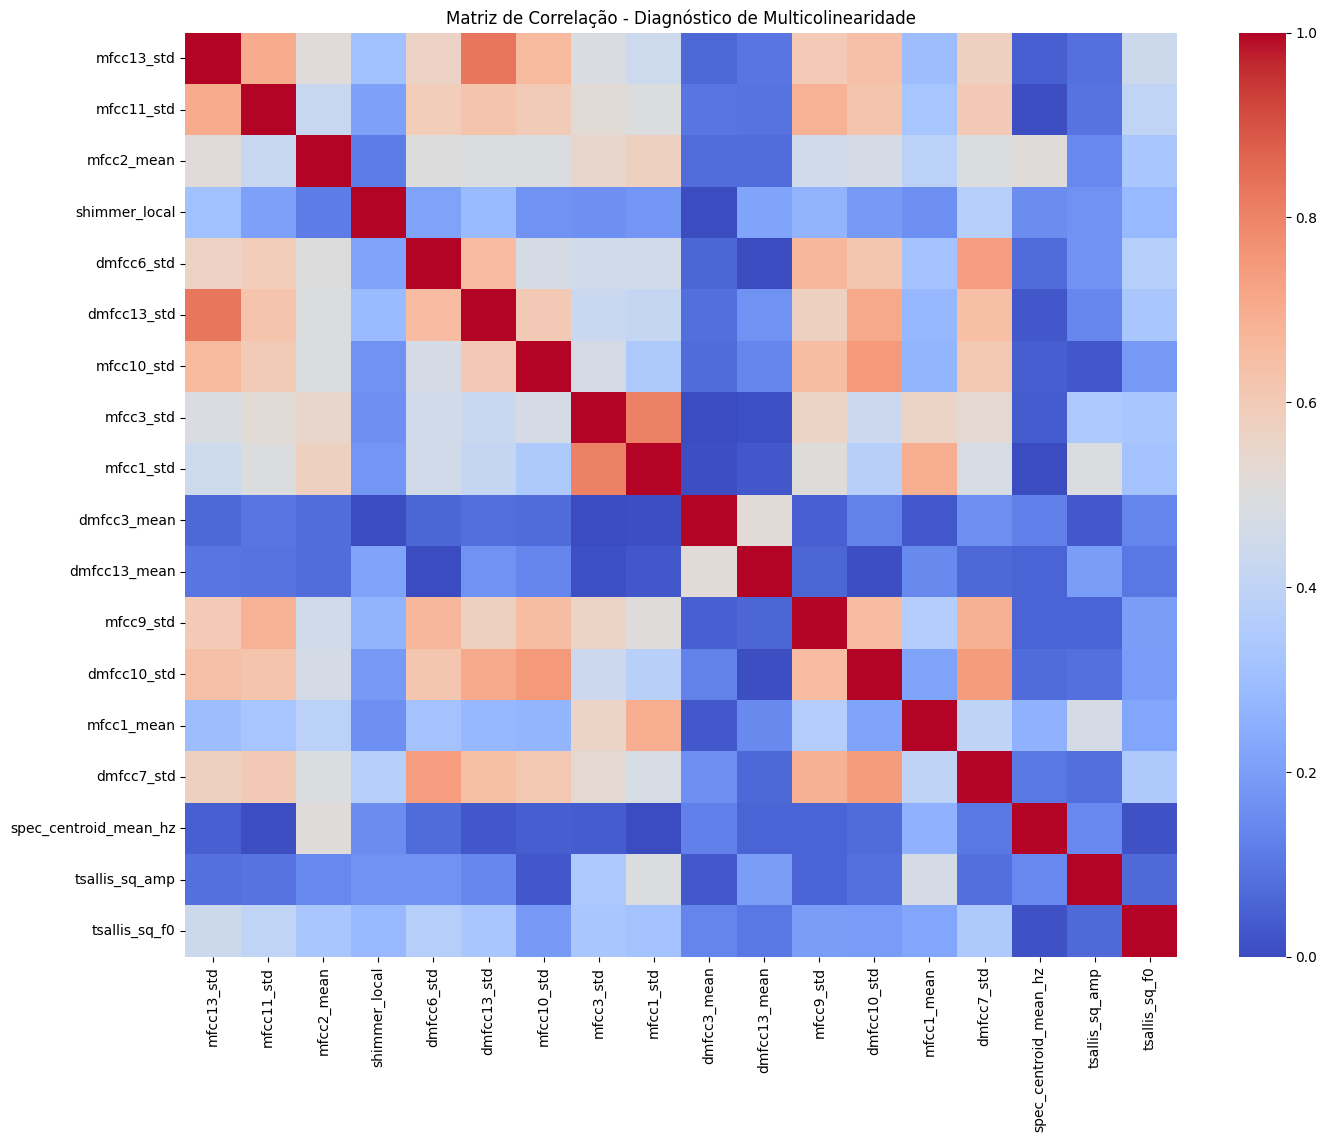


Número de colunas com correlação > 0.9: 0


In [12]:
# ============================================
# 7) analise de multicolinearidade
# ============================================

# Carregar o dataset imputado
df_analise = pd.read_csv(DATASET_TSALLIS)

# Remover colunas não numéricas para o cálculo de correlação
cols_to_exclude = ['file_name', 'group', 'status', 'subject_id']
df_numeric = df_analise.drop(columns=[col for col in cols_to_exclude if col in df.columns])

# Calcular a matriz de correlação (Pearson)
corr_matrix = df_numeric.corr().abs()

# Selecionar o triângulo superior da matriz
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identificar variáveis com correlação superior a 0.9
highly_correlated = [column for column in upper.columns if any(upper[column] > 0.9)]

# Preparar dados para visualização (top correlações)
unstacked_corr = upper.unstack().dropna()
sorted_corr = unstacked_corr.sort_values(ascending=False)

# Mostrar as 15 maiores correlações
print("Top 15 correlações mais altas:")
print(sorted_corr.head(15))

# Plotar um Heatmap das correlações
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Matriz de Correlação - Diagnóstico de Multicolinearidade")
plt.savefig('correlation_heatmap.png')
plt.show()

# Contagem de colunas problemáticas
print(f"\nNúmero de colunas com correlação > 0.9: {len(highly_correlated)}")

In [13]:
# ============================================
# 8) Função: consenso de features
# ============================================
def get_consensus_features(rf_imp, xgb_imp, cat_imp, top_k=16):
    """Combine rankings of the 3 models to obtain consensus on the best features"""

    rf_ranked = rf_imp.reset_index(drop=True)
    xgb_ranked = xgb_imp.reset_index(drop=True)
    cat_ranked = cat_imp.reset_index(drop=True)

    rf_rank_dict = {row['feature']: idx + 1 for idx, row in rf_ranked.iterrows()}
    xgb_rank_dict = {row['feature']: idx + 1 for idx, row in xgb_ranked.iterrows()}
    cat_rank_dict = {row['feature']: idx + 1 for idx, row in cat_ranked.iterrows()}

    all_features = set(rf_rank_dict.keys()) | set(xgb_rank_dict.keys()) | set(cat_rank_dict.keys())

    consensus_ranking = {}
    for feature in all_features:
        rf_pos = rf_rank_dict.get(feature, len(rf_ranked) + 1)
        xgb_pos = xgb_rank_dict.get(feature, len(xgb_ranked) + 1)
        cat_pos = cat_rank_dict.get(feature, len(cat_ranked) + 1)
        consensus_ranking[feature] = (rf_pos + xgb_pos + cat_pos) / 3

    sorted_features = sorted(consensus_ranking.items(), key=lambda x: x[1])
    return [feature for feature, _ in sorted_features[:top_k]]


In [14]:
# Pré-processamento comum
preprocess = ImbPipeline(steps=[
    ("clip", QuantileClipper(0.01, 0.99)),
    ("scale", RobustScaler())
])

X_proc = preprocess.fit_transform(X)


In [18]:

# recarregando dataset para evitar confusão com as colunas removidas por multicolinearidade
df_tsallis = pd.read_csv(DATASET_TSALLIS)
cols_to_exclude = ['status','subject_id']
feature_cols = [c for c in df_tsallis.columns if c not in cols_to_exclude]
df = df_tsallis.drop(columns=cols_to_exclude)



In [19]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_proc, y)

rf_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)



# XGBoost
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)
xgb.fit(X_proc, y)
xgb_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)


# CatBoost
cat = CatBoostClassifier(
    iterations=500,
    depth=5,
    learning_rate=0.05,
    loss_function="Logloss",
    verbose=False,
    random_seed=42
)
cat.fit(X_proc, y)
cat_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": cat.get_feature_importance()
}).sort_values("importance", ascending=False)

In [20]:
# Seleciona 18 features principais
top_features = get_consensus_features(
    rf_imp=rf_importance,
    xgb_imp=xgb_importance,
    cat_imp=cat_importance,
    top_k=18
)

print("Top 16 features por consenso:")
for f in top_features:
    print("-", f)

Top 16 features por consenso:
- mfcc13_std
- shimmer_local
- mfcc11_std
- dmfcc3_mean
- mfcc1_std
- mfcc9_std
- mfcc2_mean
- mfcc10_std
- tsallis_sq_amp
- mfcc3_std
- mfcc1_mean
- dmfcc6_std
- dmfcc7_std
- dmfcc13_std
- spec_centroid_mean_hz
- dmfcc13_mean
- dmfcc10_std
- tsallis_sq_f0


In [23]:
# ============================================
# 9) Definir as features selecionadas (Top-18)
# ============================================

selected_features = top_features
# selected_features = [
#     "mfcc13_std", 
#     "shimmer_local",
#     "mfcc11_std",
#     "dmfcc3_mean",
#     "mfcc1_std",
#     "mfcc9_std",
#     "mfcc2_mean",
#     "mfcc10_std", 
#     "tsallis_sq_amp",
#     "mfcc3_std", 
#     "mfcc1_mean",
#     "dmfcc6_std",
#     "dmfcc7_std",
#     "dmfcc13_std",
#     "spec_centroid_mean_hz",    
#     "dmfcc13_mean",
#     "dmfcc10_std",
#     "tsallis_sq_f0",
# ]

# selected_features = [
#     "mfcc11_std",
#     "mfcc13_std", 
#     "mfcc1_std", 
#     "mfcc10_std", 
#     "dmfcc3_mean",
#     "dmfcc13_std",
#     "tsallis_sq_amp",
#     "mfcc9_std",
#     "shimmer_local",
#     "mfcc8_std",
#     "mfcc12_std",
#     "spec_rolloff_std_hz",
#     "mfcc1_mean",
#     "dmfcc13_mean",
#     "dmfcc7_std",
#     "shimmer_apq3",
# ]

missing = set(selected_features) - set(df.columns)
if missing:
    raise ValueError(f"Colunas selecionadas não encontradas no dataset: {missing}")


In [26]:
def make_pipeline(model):
    return ImbPipeline(steps=[
        # 1. Imputação: Garante que não haja nulos entrando nos transformadores
        ("imputer", SimpleImputer(strategy='median')),

        # 2. Clipping: Amortece os outliers extremos antes do escalonamento
        ("clip", QuantileClipper(0.01, 0.99)),
        
        # 3. RobustScaler: Escalonamento robusto baseado em quartis
        ("scale", RobustScaler()),

        # 4. SMOTE: Balanceamento sintético aplicado apenas durante o 'fit' (treino)
        ("smote", SMOTE(random_state=42, k_neighbors=3)),

        # 5. O Classificador (SVC, XGBoost, etc.)
        ("clf", model)
    ])
    

In [27]:
# =========================================================
# 13) Benchmark: roda GroupKFold CV e devolve tabela resumo
# =========================================================
def benchmark_models(X, y, groups, models_dict, n_splits=5, n_jobs=1):
    cv = GroupKFold(n_splits=n_splits)

    scoring = {
        "bal_acc": "balanced_accuracy",
        "roc_auc": "roc_auc",
        "f1": "f1",
    }

    rows = []
    for name, model in models_dict.items():
        pipe = make_pipeline(model)

        scores = cross_validate(
            pipe, X, y,
            groups=groups,
            cv=cv,
            scoring=scoring,
            n_jobs=n_jobs,
            error_score="raise"
        )

        rows.append({
            "model": name,
            "bal_acc_mean": float(np.mean(scores["test_bal_acc"])),
            "bal_acc_std":  float(np.std(scores["test_bal_acc"])),
            "roc_auc_mean": float(np.mean(scores["test_roc_auc"])),
            "roc_auc_std":  float(np.std(scores["test_roc_auc"])),
            "f1_mean":      float(np.mean(scores["test_f1"])),
            "f1_std":       float(np.std(scores["test_f1"])),
        })

    return pd.DataFrame(rows).sort_values("bal_acc_mean", ascending=False).reset_index(drop=True)


In [28]:
# =========================================================
# 14) Carregar dataset para benchmarking
# =========================================================
df = pd.read_csv(DATASET_TSALLIS)
feature_cols = [c for c in df.columns if c not in ["status", "subject_id"]]

X = df[feature_cols].values
y = df["status"].astype(int).values
groups = df["subject_id"].values

print("Dataset usado:", DATASET_TSALLIS)
print("Shape:", df.shape)
print("Nº features:", len(feature_cols))
print("Nº sujeitos:", df["subject_id"].nunique())
print("Balanceamento:", pd.Series(y).value_counts().to_dict())

Dataset usado: dataset_tsallis.csv
Shape: (81, 20)
Nº features: 18
Nº sujeitos: 81
Balanceamento: {0: 41, 1: 40}


In [29]:
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
# =========================================================
# 15) Modelos (SEM CatBoost)
# =========================================================
RNG_SEED = 42

models = {
    "logreg_l2": LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="liblinear",
            max_iter=5000,
            class_weight="balanced",
            random_state=RNG_SEED,
            fit_intercept=True,
        ),
    "svc_rbf":  SVC(
            C=100.0,
            gamma=0.1,
            kernel="rbf",
            probability=False,          # necessário para ROC-AUC via predict_proba
            class_weight="balanced",
            random_state=RNG_SEED,      # usado na calibração interna do probability=True
        ),
    # LinearSVC não tem predict_proba -> calibramos para ter probabilidade para ROC-AUC
    "linear_svc_cal": CalibratedClassifierCV(
            estimator=LinearSVC(
                C=1.0,
                class_weight="balanced",
                random_state=RNG_SEED,
                max_iter=10000,
            ),
            method="sigmoid",
            cv=3,
        ),
    # -------------------------
    # Árvores / Ensembles
    # -------------------------
    "random_forest": RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_split=10,
            min_samples_leaf=5,
            max_features="sqrt",
            bootstrap=True,
            class_weight="balanced",
            random_state=RNG_SEED,
            n_jobs=-1,
        ),
    "gradient_boosting": GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            subsample=1.0,
            random_state=RNG_SEED,
        ),
    "adaboost": AdaBoostClassifier(
            n_estimators=100,
            learning_rate=1.0,            
            random_state=RNG_SEED,
        ),
    "decision_tree": DecisionTreeClassifier(
            criterion="gini",
            max_depth=5,
            min_samples_split=2,
            min_samples_leaf=1,
            random_state=RNG_SEED,
        ),
    # -------------------------
    # KNN (não tem random_state)
    # -------------------------
    "knn": KNeighborsClassifier(
            n_neighbors=7,
            weights="distance",
            metric="minkowski",
            p=2,
        ),
    
    # -------------------------
    # MLP (rede rasa)
    # -------------------------
    "mlp": MLPClassifier(
            hidden_layer_sizes=(50, 50),
            activation="relu",
            solver="adam",
            alpha=0.0001,
            learning_rate="constant",
            learning_rate_init=0.001,
            max_iter=2000,
            tol=1e-5,
            early_stopping=False,
            random_state=RNG_SEED,
        ),
    # -------------------------
    # XGBoost / CatBoost
    # -------------------------
    "xgboost": XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=1.0,
            reg_lambda=1.0,
            reg_alpha=0.0,
            gamma=0.0,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RNG_SEED,
            n_jobs=-1,
            verbosity=0,
        ),

}


In [30]:
# =========================================================
# 16) Rodar benchmark (GroupKFold por sujeito)
# =========================================================
results = benchmark_models(X, y, groups, models, n_splits=5, n_jobs=1)

# Mostrar ranking
print("\n=== Ranking por Balanced Accuracy (GroupKFold, sem leakage) ===")
print(results)


=== Ranking por Balanced Accuracy (GroupKFold, sem leakage) ===
               model  bal_acc_mean  bal_acc_std  roc_auc_mean  roc_auc_std  \
0      random_forest      0.763889     0.099865      0.810764     0.059759   
1           adaboost      0.752778     0.052997      0.854861     0.090960   
2                knn      0.740278     0.071173      0.818924     0.058714   
3            xgboost      0.727778     0.108155      0.780903     0.100349   
4          logreg_l2      0.713889     0.085436      0.788889     0.110658   
5  gradient_boosting      0.694444     0.084483      0.748264     0.104016   
6                mlp      0.676389     0.109326      0.755208     0.063105   
7     linear_svc_cal      0.676389     0.122080      0.764583     0.129745   
8            svc_rbf      0.652778     0.096625      0.730556     0.047092   
9      decision_tree      0.620833     0.068971      0.620833     0.068971   

    f1_mean    f1_std  
0  0.761654  0.093273  
1  0.745088  0.070359  
2  0